## Double pendulum dataset

In [ ]:
import os
import torch
while not os.getcwd().endswith("ScalarEMLP"):
    os.chdir("../")


(5000, 5, 12)
(5, 12)


In [ ]:
# print(os.getcwd())
root_dir=os.path.join(os.getcwd(), *"experiments/datasets/ODEDynamics/DoubleSpringPendulum".split("/"))
file_name=os.path.join(root_dir,"trajectories_5000_5_0.2_30.pz")
zs=torch.load(file_name, weights_only=False)

print(zs.shape)
print(zs[0].shape)

# p1=os.path.join(os.getcwd(), *"datasets/ODEDynamics/DoubleSpringPendulum".split("/"))
# print(p1)

(5000, 5, 12)
(5, 12)


: 

In [3]:
import numpy as np 
from experiments.trainer.hamiltonian_dynamics import *


## 3D visualization

In [4]:
from experiments.trainer.hamiltonian_dynamics import CoupledPendulumAnimation

import numpy as np
from IPython.display import HTML

# Convert from torch.Tensor to numpy
qt = zs[:,:,:3]  # (T, n, d)
# print(qt)


# Visualize
# ani = CoupledPendulumAnimation(qt)
# HTML(ani.animate())

<PjitFunction of <function hamiltonian_dynamics at 0x00000184B4915BC0>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184B4A1DD00>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184B4A1F2E0>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184B6D84540>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184B6D85BC0>>
<PjitFunction of <function hamiltonian_dynamics at 0x000001849DB36200>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184B6D86B60>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BAB3C540>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BAB3DE40>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BAB3F240>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BC2C0400>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BC2C18A0>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BC2C2F20>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184BC2

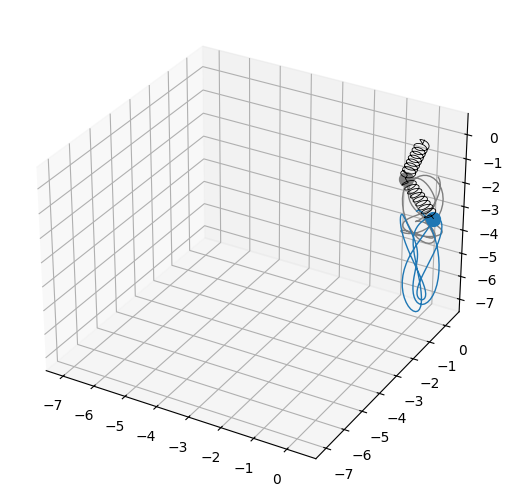

In [5]:
from experiments.trainer.hamiltonian_dynamics import *
from experiments.trainer.hamiltonian_dynamics import DoubleSpringPendulum
from IPython.display import HTML
ndata=5000
data_config={'chunk_len':5,'dt':0.2,'integration_time':30,'regen':False}
dsp=DoubleSpringPendulum(n_systems=ndata,**data_config)


anim=dsp.animate()
HTML(anim)  # In Jupyter Notebook

In [9]:
n_systems, dt, integration_time,chunk_len=500,0.2,30,5
zs = dsp.generate_trajectory_data(n_systems, dt, integration_time)
Zs = np.asarray(dsp.chunk_training_data(zs, chunk_len))
os.makedirs(root_dir, exist_ok=True)
root_dir = os.path.join(os.getcwd(), *f"datasets/ODEDynamics/{dsp.__class__.__name__}".split("/"))
filename = os.path.join(root_dir, f"trajectories_{n_systems}_{chunk_len}_{dt}_{integration_time}.pt")
# torch.save(Zs, filename)

<PjitFunction of <function hamiltonian_dynamics at 0x00000184E694D080>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184E6E536A0>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184E6E94680>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184E6E95F80>>
<PjitFunction of <function hamiltonian_dynamics at 0x00000184E6E97380>>


In [ ]:
import torch
import numpy


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\ylu174\\my_file\\research\\bilipschitz_scalars_EML\\bilipschitz_experiment\\ScalarEMLP\\datasets\\ODEDynamics\\DoubleSpringPendulum\\trajectories_500_5_0.2_30.pt'

## dataset analysis

In [ ]:
ndata=5000
data_config={'chunk_len':5,'dt':0.2,'integration_time':30,'regen':False}
dsp=DoubleSpringPendulum(n_systems=ndata,**data_config)

# data length
print("data length:", len(dsp))

# chunk length
print("chunk length:",dsp.T)

# whole trajectory length
print("whole trajectory length:",dsp.T_long)

# trajectory data shape
print("trajectory data shape:", dsp.Zs.shape)

# trajectory data sample
print("trajectory data sample:", dsp.Zs[0])



data length: 5000
chunk length: [0.  0.2 0.4 0.6 0.8]
whole trajectory length: [ 0.         0.2        0.4        0.6        0.8        1.
  1.2        1.4        1.6        1.8000001  2.         2.2
  2.4        2.6000001  2.8        3.         3.2        3.4
  3.6000001  3.8        4.         4.2000003  4.4        4.6
  4.8        5.         5.2000003  5.4        5.6        5.8
  6.         6.2000003  6.4        6.6        6.8        7.
  7.2000003  7.4        7.6        7.8        8.         8.2
  8.400001   8.6        8.8        9.         9.2        9.400001
  9.6        9.8       10.        10.2       10.400001  10.6
 10.8       11.        11.2       11.400001  11.6       11.8
 12.        12.2       12.400001  12.6       12.8       13.
 13.2       13.400001  13.6       13.8       14.        14.2
 14.400001  14.6       14.8       15.        15.2       15.400001
 15.6       15.8       16.        16.2       16.4       16.6
 16.800001  17.        17.2       17.4       17.6       17.8

In [ ]:
from torchview import draw_graph
# print(os.getcwd())

# Load your model from the .t file
# model = torch.load("experiments/hnn_results/scalars_HNNs_1.t") 
# print(model)
# model_graph = draw_graph(model, input_size=(1, 3, 224, 224), expand_nested=True) # Adjust input_size
# model_graph.visual_graph 